In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
DATA_PATH = "/kaggle/input/datasets/ramdayal51/speech-emotion-recognition/Dataset-1/Dataset"

emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print("Emotions:", emotions)

Emotions: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean

In [4]:
X = []  
y = []  

for emotion in emotions:
    folder_path = os.path.join(DATA_PATH, emotion)

    if not os.path.exists(folder_path):
        print(f"worning: {folder_path}")
        continue

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".wav"):
            file_path = os.path.join(folder_path, file_name)

            try:
                features = extract_features(file_path)
                X.append(features)
                y.append(emotion)
            except Exception as e:
                print(f"Erorr file:{file_path}: {e}")

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2556, 40)
Shape of y: (2556,)


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Classes: ['anger' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
Train size: 2044
Test size: 512


In [6]:
model = MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42)

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       anger       0.89      0.80      0.84        87
     disgust       0.58      0.51      0.54        51
        fear       0.63      0.64      0.64        87
       happy       0.76      0.75      0.76        87
     neutral       0.78      0.81      0.79        62
         sad       0.67      0.70      0.69        87
    surprise       0.61      0.71      0.65        51

    accuracy                           0.71       512
   macro avg       0.70      0.70      0.70       512
weighted avg       0.71      0.71      0.71       512



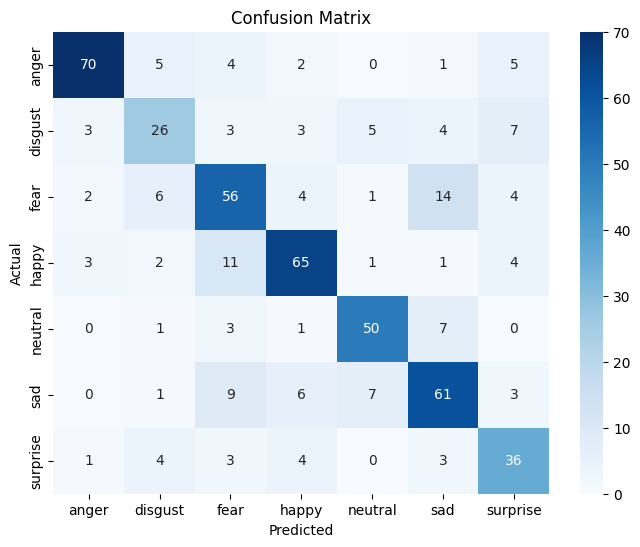

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
def predict_emotion(file_path):
    features = extract_features(file_path)

    features_scaled = scaler.transform([features])

    prediction = model.predict(features_scaled)

    emotion_name = label_encoder.inverse_transform(prediction)

    return emotion_name[0]

In [10]:
import joblib

joblib.dump(model, 'gender_age_model.pkl')

['gender_age_model.pkl']